# Banking Fraud Detection — Cost-Sensitive Classification

This notebook applies cost-sensitive classification to give greater importance to fraudulent transactions and reduce the cost of missed fraud.

In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [4]:
train_df = pd.read_csv("../data/train_temporal.csv")
test_df = pd.read_csv("../data/test_temporal.csv")

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

Training data: (8000, 10)
Testing data: (2000, 10)


In [5]:
target = "is_fraud"

drop_columns = [
    "is_fraud",
    "transaction_id",
    "customer_id",
    "timestamp"
]

X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target]

X_test = test_df.drop(columns=drop_columns)
y_test = test_df[target]

In [6]:
categorical_features = [
    "merchant_category",
    "customer_location",
    "device_type"
]

numerical_features = [
    "amount",
    "customer_age",
    "previous_transactions"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_cat = encoder.transform(
    X_test[categorical_features]
)

X_train_num = X_train[numerical_features].values
X_test_num = X_test[numerical_features].values

X_train_final = np.hstack([
    X_train_num,
    X_train_cat
])

X_test_final = np.hstack([
    X_test_num,
    X_test_cat
])

In [7]:
cost_sensitive_model = LogisticRegression(
    class_weight={0: 1, 1: 5},
    max_iter=1000
)

In [8]:
cost_sensitive_model.fit(
    X_train_final,
    y_train
)

LogisticRegression(class_weight={0: 1, 1: 5}, max_iter=1000)

In [9]:
y_pred = cost_sensitive_model.predict(X_test_final)

y_prob = cost_sensitive_model.predict_proba(
    X_test_final
)[:, 1]

cost_sensitive_results = {
    "Model": "Cost-Sensitive Logistic Regression",
    "Precision": precision_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "PR-AUC": average_precision_score(
        y_test,
        y_prob
    )
}

cost_sensitive_results

{'Model': 'Cost-Sensitive Logistic Regression',
 'Precision': np.float64(0.0),
 'Recall': np.float64(0.0),
 'F1-Score': np.float64(0.0),
 'PR-AUC': np.float64(0.022300185701745252)}

In [12]:
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

for threshold in thresholds:

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.5 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
Threshold: 0.4 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
Threshold: 0.3 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
Threshold: 0.2 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
Threshold: 0.1 | Precision: 0.0185 | Recall: 0.2045 | F1: 0.0340


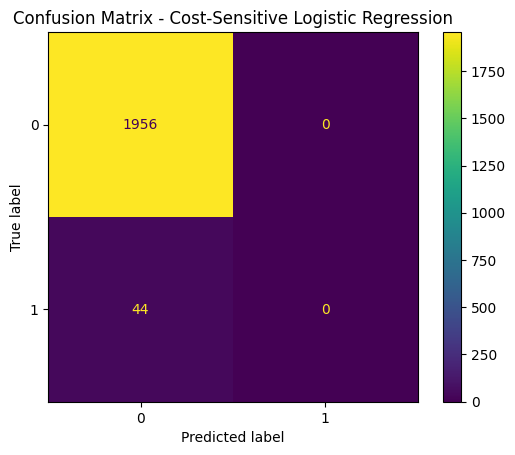

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix - Cost-Sensitive Logistic Regression")
plt.show()

In [11]:
comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression - Baseline",
        "Precision": 0.000000,
        "Recall": 0.000000,
        "F1-Score": 0.000000,
        "PR-AUC": 0.022365
    },
    {
        "Model": "Logistic Regression - SMOTE",
        "Precision": 0.024859,
        "Recall": 0.500000,
        "F1-Score": 0.047363,
        "PR-AUC": 0.021837
    },
    cost_sensitive_results
])

comparison

,Model,Precision,Recall,F1-Score,PR-AUC
0,Logistic Regression - Baseline,0.000000,0.0,0.000000,0.022365
1,Logistic Regression - SMOTE,0.024859,0.5,0.047363,0.021837
2,Cost-Sensitive Logistic Regression,0.000000,0.0,0.000000,0.022300


### Observations

- Cost-sensitive Logistic Regression was trained by assigning a higher weight to the fraud class.
- With the default classification threshold of 0.5, the model achieved zero recall on the temporal test set.
- Lowering the threshold to 0.1 increased recall to 0.2045, but precision remained very low at 0.0185.
- This shows that classification threshold selection has a significant effect on fraud detection performance.
- Compared with SMOTE, the tested cost-sensitive configuration did not provide better fraud detection performance.
- The results demonstrate that handling class imbalance requires consideration of both class distribution and the relative cost of false negatives and false positives.